<center>
  <img src="https://comunicacioninstitucional.uabc.mx/v1/sites/default/files/inline-images/Escudo_0_0.png" width="220" alt="Logo UABC">
  <br><br>

  <table style="border-collapse: collapse; border: none; margin: 0 auto;">
    <tr style="border: none; background-color: transparent;">
      <td style="border: none; text-align: center; padding: 0 15px;">
        <img src="https://raw.githubusercontent.com/ArmandoRamirez951/Ciencia-de-Datos/main/yael.jpg" width="130" height="130" style="border-radius: 50%; border: 3px solid #b7902d; object-fit: cover;">
        <br><br><b></b>
      </td>
      <td style="border: none; text-align: center; padding: 0 15px;">
        <img src="https://raw.githubusercontent.com/ArmandoRamirez951/Ciencia-de-Datos/main/alexis.jpeg" width="130" height="130" style="border-radius: 50%; border: 3px solid #b7902d; object-fit: cover;">
        <br><br><b></b>
      </td>
      <td style="border: none; text-align: center; padding: 0 15px;">
        <img src="https://raw.githubusercontent.com/ArmandoRamirez951/Ciencia-de-Datos/main/armando.jpg" width="130" height="130" style="border-radius: 50%; border: 3px solid #b7902d; object-fit: cover;">
        <br><br><b></b>
      </td>
    </tr>
  </table>
</center>

<br>

<div style="text-align: center;">

# **Universidad Autónoma de Baja California**
## **Facultad de Contaduría y Administración**
## **Inteligencia de Negocios**

### **Proyecto Final:** Meta 4.1 Proyecto Integrador de Ciencia de Datos utilizando la metodología CRISP-DM
### **Integrantes:**
- De La Cruz Ramirez Jeremy Yael
- Garnica Mendoza Jesus Alexis
- Ramirez Cardenas Luis Armando
### **Grupo:** 971
### **Fecha:** 03/06/2026
### **Profesor:** Josue Miguel Flores Parra

</div>

# Fundamento Teórico del Entorno de Trabajo

Para la resolución de este proyecto, se estructuró un entorno de trabajo basado en las librerías estándar de la Ciencia de Datos, seleccionadas por su función matemática y computacional en el ciclo de vida del modelado:

* pandas (Manipulación de Datos): Esencial para estructurar los datos en formato tabular (DataFrames), permitiendo la limpieza, transformación y el análisis estadístico descriptivo.
* numpy (Análisis Matemático): Proporciona la base fundacional al permitir el procesamiento eficiente de arreglos multidimensionales y álgebra lineal para los algoritmos.
* matplotlib y seaborn (Visualización de Datos): Librerías estadísticas que permiten proyectar los datos cartesianamente y crear gráficas complejas (como mapas de calor) para entender la correlación entre variables.
* train_test_split (Validación): Implementa el principio Hold-out. Divide el dataset en dos conjuntos aislados para entrenar el modelo y evaluar empíricamente su capacidad de generalización.
* StandardScaler (Preprocesamiento): Aplica normalización Z-score. Escala las variables numéricas para evitar que características con magnitudes grandes dominen el cálculo de las distancias.
* KNeighborsClassifier (KNN): Algoritmo de aprendizaje basado en instancias que clasifica nuevos puntos midiendo la distancia matemática (ej. Euclidiana) hacia sus vecinos más cercanos.
* DecisionTreeClassifier (Árbol de Decisión): Modelo basado en la teoría de la información que crea ramificaciones evaluando métricas de impureza (Gini/Entropía) para encontrar reglas lógicas de partición.
* RandomForestClassifier (Bosque Aleatorio): Arquitectura de aprendizaje ensamblado (Bagging). Construye múltiples árboles independientes y promedia sus resultados para reducir la varianza y el riesgo de sobreajuste.
* accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve y roc_auc_score (Evaluación): Conjunto integral de métricas para auditar problemas desbalanceados. El Accuracy mide los aciertos generales; Precision y Recall evalúan el desempeño específico sobre la clase crítica (fuga); el F1-Score las balancea armónicamente; la matriz de confusión visualiza los cuadrantes de error; y la curva ROC junto al AUC miden la capacidad de separación probabilística del modelo.

In [ ]:
# ========================================================
# IMPORTACIÓN DE LIBRERÍAS Y ENTORNO DE TRABAJO
# ========================================================

# 1. Manipulación y análisis matemático de datos
import pandas as pd
import numpy as np

# 2. Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Preparación de datos y validación
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 4. Algoritmos de Machine Learning
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 5. Métricas de evaluación (Clasificación)
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             confusion_matrix,
                             roc_curve,
                             roc_auc_score)

# Configuración estética opcional para las gráficas
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore') # Oculta advertencias futuras de las librerías

print("Entorno de trabajo configurado y librerías importadas correctamente.")

Entorno de trabajo configurado y librerías importadas correctamente.


# Fundamento Teórico de la Comprensión de Datos (EDA)

El Análisis Exploratorio de Datos (EDA) es el pilar analítico para entender la distribución, integridad y relación de las variables antes del modelado matemático. Sus técnicas se justifican de la siguiente manera:

* Inspección Estructural (head, info): Valida la dimensión del dataset, identifica los tipos de datos y descarta variables sin valor predictivo (como el customerID).
* Integridad e Imputación (isnull, fillna): Como los algoritmos no procesan vacíos (NaN), se detectan nulos ocultos y se aplica una imputación lógica (ej. asignar 0 a los cargos totales de clientes nuevos sin facturación).
* Estadística Descriptiva (describe): Calcula medidas de tendencia central y dispersión para mapear el comportamiento numérico de los clientes y detectar valores atípicos (outliers).
* Correlación de Pearson (corr): Cuantifica matemáticamente la relación lineal entre los datos numéricos y la variable objetivo (Churn), evaluando su poder predictivo con valores de -1 a 1.
* Histograma: Proyecta la frecuencia de variables continuas (como la antigüedad) para visualizar en qué etapa del ciclo comercial se concentra la mayor tasa de abandono.
* Diagrama de Caja (Boxplot): Compara visualmente la variabilidad y las medianas de los datos (como los cobros mensuales) entre clientes leales y fugitivos utilizando percentiles estadísticos.
* Gráfico de Dispersión (Scatterplot): Intersecta dos variables continuas en un plano cartesiano para identificar visualmente agrupaciones geométricas o correlaciones espaciales.
* Mapa de Calor (Heatmap): Es la traducción visual de la matriz de Pearson. Usa la densidad de color para resaltar qué características detonan la fuga y descartar la redundancia matemática (multicolinealidad).

=== 1. PRIMERAS FILAS (head) ===


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes




=== 2. INFORMACIÓN ESTRUCTURAL (info) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000




=== 5. CORRELACIONES ENTRE VARIABLES ===


,tenure,MonthlyCharges,TotalCharges,Churn_num
tenure,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.826178,0.651174,1.000000,-0.198324
Churn_num,-0.352229,0.193356,-0.198324,1.000000




=== 6. VISUALIZACIONES Y GRÁFICAS ===


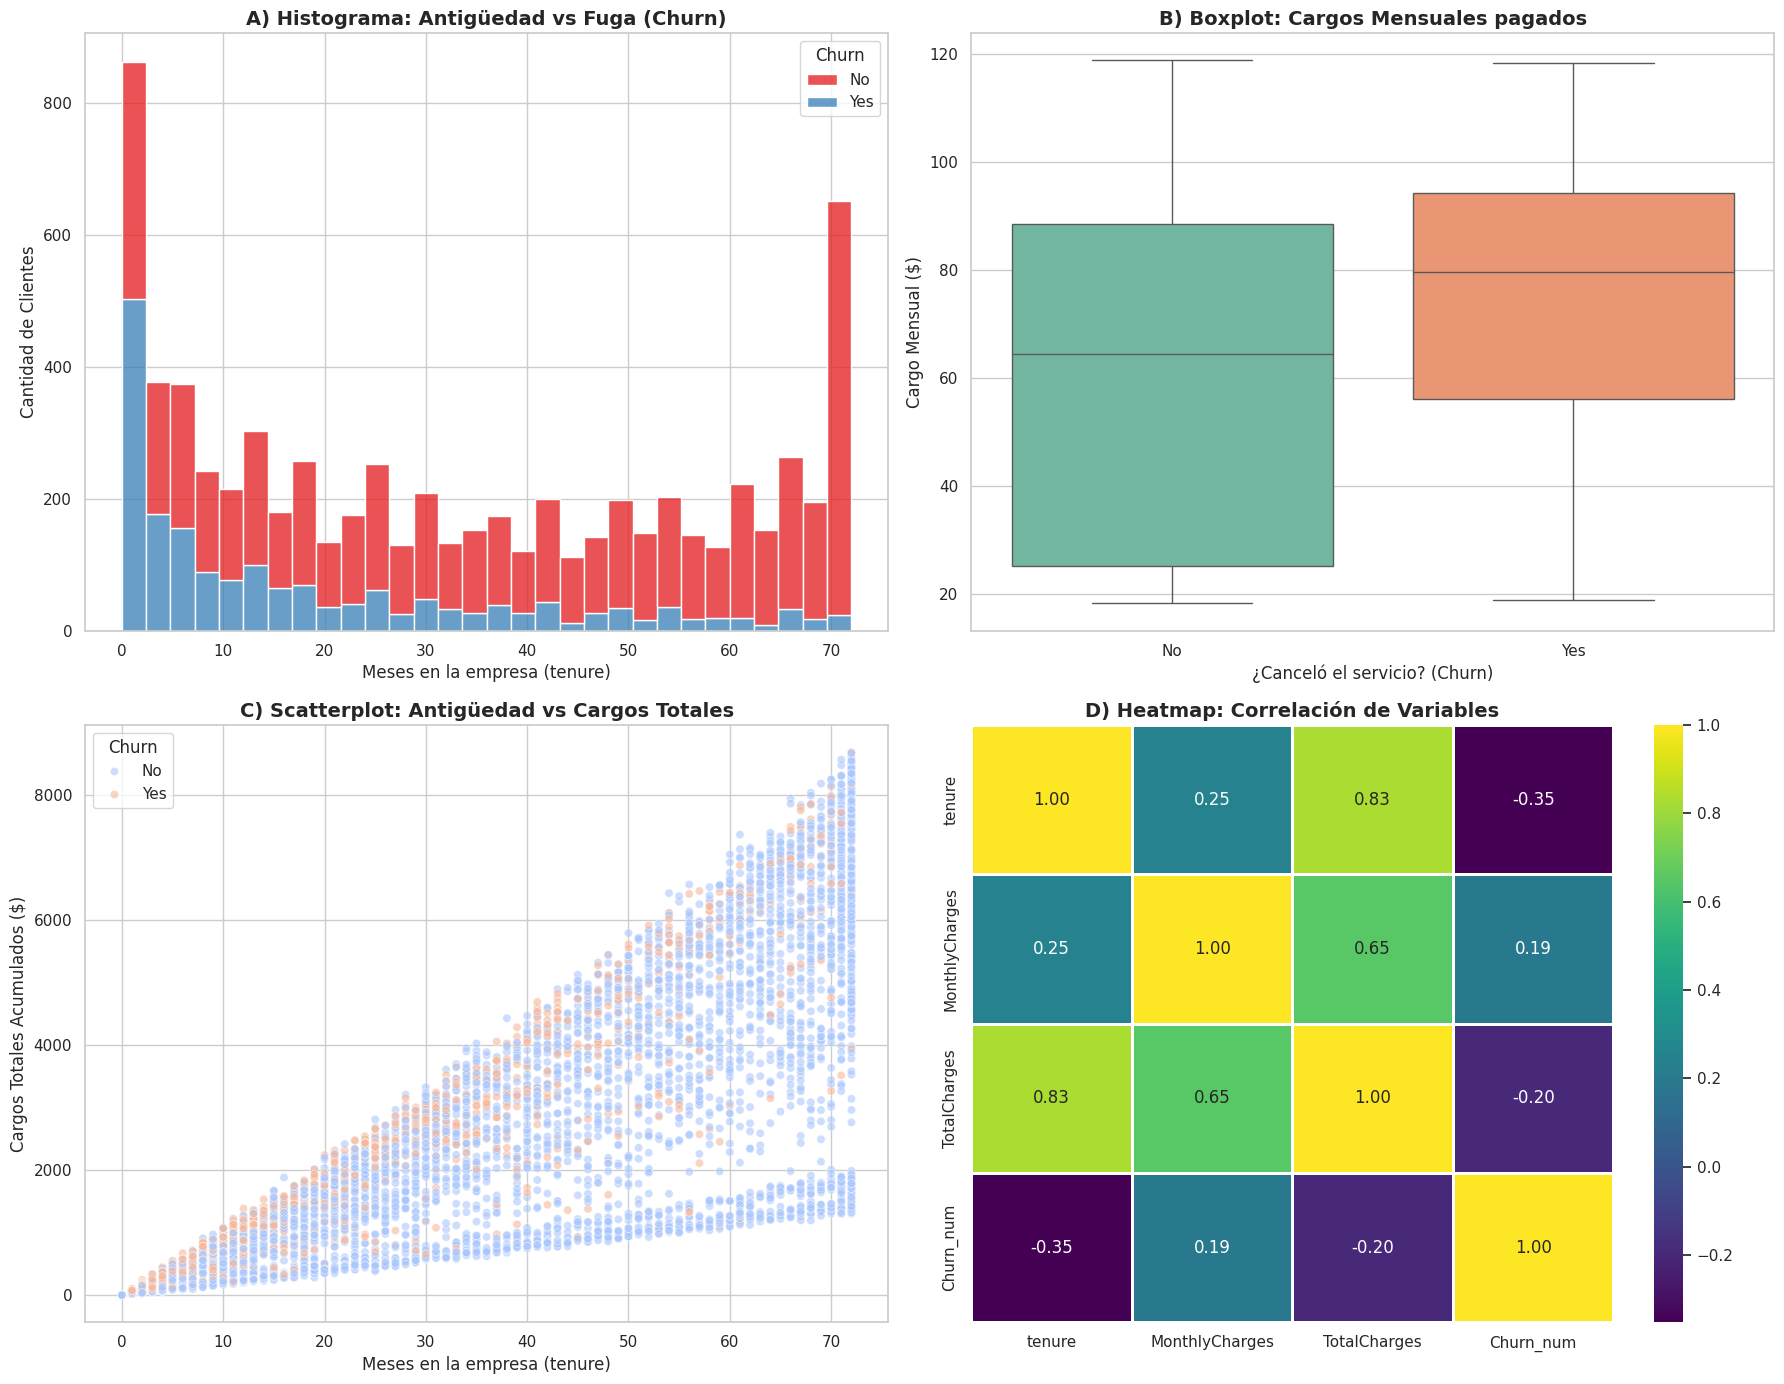

In [ ]:
# ========================================================
# FASE DE COMPRENSIÓN DE LOS DATOS
# ========================================================

# 1. CARGAR EL DATASET
url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Limpieza inicial básica para el análisis
df.drop('customerID', axis=1, inplace=True, errors='ignore')

print("=== 1. PRIMERAS FILAS (head) ===")
display(df.head())
print("\n" + "="*50 + "\n")

print("=== 2. INFORMACIÓN ESTRUCTURAL (info) ===")
df.info()
print("\n" + "="*50 + "\n")

print("=== 3. ANÁLISIS DE VALORES NULOS ===")
print("Nulos detectados inicialmente:")
print(df.isnull().sum()[df.isnull().sum() > 0]) # Mostrará vacío

print("\nBuscando nulos ocultos en 'TotalCharges'...")
# Convertimos el texto a número. Los espacios vacíos se volverán NaN (Nulos)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
nulos_descubiertos = df['TotalCharges'].isnull().sum()
print(f"¡Se encontraron {nulos_descubiertos} valores nulos ocultos!")

# Imputamos con 0 (clientes nuevos que no han pagado) para poder graficar
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("\n" + "="*50 + "\n")

print("=== 4. ESTADÍSTICAS DESCRIPTIVAS (describe) ===")
display(df.describe())
print("\n" + "="*50 + "\n")

print("=== 5. CORRELACIONES ENTRE VARIABLES ===")
# Convertimos Churn temporalmente a números (Yes=1, No=0) para la correlación
df['Churn_num'] = df['Churn'].map({'Yes': 1, 'No': 0})
variables_numericas = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_num']]
matriz_corr = variables_numericas.corr()
display(matriz_corr)
print("\n" + "="*50 + "\n")

print("=== 6. VISUALIZACIONES Y GRÁFICAS ===")

# Configurar el lienzo de gráficas (2 filas, 2 columnas)
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# A) HISTOGRAMA: Distribución de la Antigüedad (tenure)
sns.histplot(ax=axes[0,0], data=df, x='tenure', hue='Churn', multiple='stack', bins=30, palette='Set1')
axes[0,0].set_title('A) Histograma: Antigüedad vs Fuga (Churn)', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Meses en la empresa (tenure)')
axes[0,0].set_ylabel('Cantidad de Clientes')

# B) BOXPLOT: Cargos Mensuales vs Churn
sns.boxplot(ax=axes[0,1], data=df, x='Churn', y='MonthlyCharges', palette='Set2')
axes[0,1].set_title('B) Boxplot: Cargos Mensuales pagados', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('¿Canceló el servicio? (Churn)')
axes[0,1].set_ylabel('Cargo Mensual ($)')

# C) SCATTERPLOT: Antigüedad vs Cargos Totales
sns.scatterplot(ax=axes[1,0], data=df, x='tenure', y='TotalCharges', hue='Churn', alpha=0.6, palette='coolwarm')
axes[1,0].set_title('C) Scatterplot: Antigüedad vs Cargos Totales', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Meses en la empresa (tenure)')
axes[1,0].set_ylabel('Cargos Totales Acumulados ($)')

# D) HEATMAP: Matriz de Correlación
sns.heatmap(ax=axes[1,1], data=matriz_corr, annot=True, cmap='viridis', fmt=".2f", linewidths=1)
axes[1,1].set_title('D) Heatmap: Correlación de Variables', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Limpiamos la columna temporal creada
df.drop('Churn_num', axis=1, inplace=True)

# Fundamento Teórico de la Preparación de los Datos (Preprocesamiento)

La fase de Preparación de Datos transforma la información bruta en tensores numéricos aptos para Machine Learning, basándose en los siguientes principios estadísticos:

* Tratamiento Homogéneo de Datos: La conversión forzada a numérico y la imputación lógica eliminan inconsistencias textuales que interrumpirían los cálculos algebraicos durante el entrenamiento.
* Codificación Categórica (Encoding): Los algoritmos requieren números. El Mapeo Binario y el One-Hot Encoding (get_dummies) transforman el texto en vectores de 0 y 1. Usar drop_first=True es vital para evitar la multicolinealidad perfecta (trampa de la variable ficticia).
* División Estratificada (Train/Test Split): Separar los datos (80% entrenamiento, 20% prueba) permite evaluar la generalización del modelo. El parámetro stratify=y garantiza que se mantenga la proporción exacta de clientes leales y fugitivos en ambos subconjuntos.
* Escalamiento Estándar (StandardScaler): Estandariza variables numéricas con magnitudes dispares para que tengan media 0 y varianza 1. Esto es indispensable para que algoritmos basados en distancias geométricas (como KNN) no generen sesgos.
* Prevención de Fuga de Datos (Data Leakage): El escalador se entrena (fit_transform) estrictamente con los datos de entrenamiento. Al conjunto de prueba solo se le aplica la transformación (transform), aislando matemáticamente el experimento para evitar que el modelo obtenga información adelantada sobre los datos que debe predecir.

1. Seleccionando variables y limpiando datos...
2. Aplicando Encoding a variables categóricas...
3. Dividiendo el dataset en Entrenamiento (Train) y Prueba (Test)...
4. Escalando variables numéricas...

=== RESUMEN DE LA PREPARACIÓN ===
Tamaño de Entrenamiento (X_train): (5634, 30)
Tamaño de Prueba (X_test): (1409, 30)

Primeras filas listas para el modelo:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,0,0.102371,-0.521976,-0.262257,True,False,False,False,True,False,...,False,True,False,True,False,False,False,False,True,False
3151,0,-0.711743,0.337478,-0.503635,True,True,True,True,False,False,...,False,False,False,False,False,False,False,False,False,True
4860,0,-0.793155,-0.809013,-0.749883,True,True,True,False,True,False,...,False,False,False,False,False,True,False,False,False,True



Generando gráficas diagnósticas de preparación...


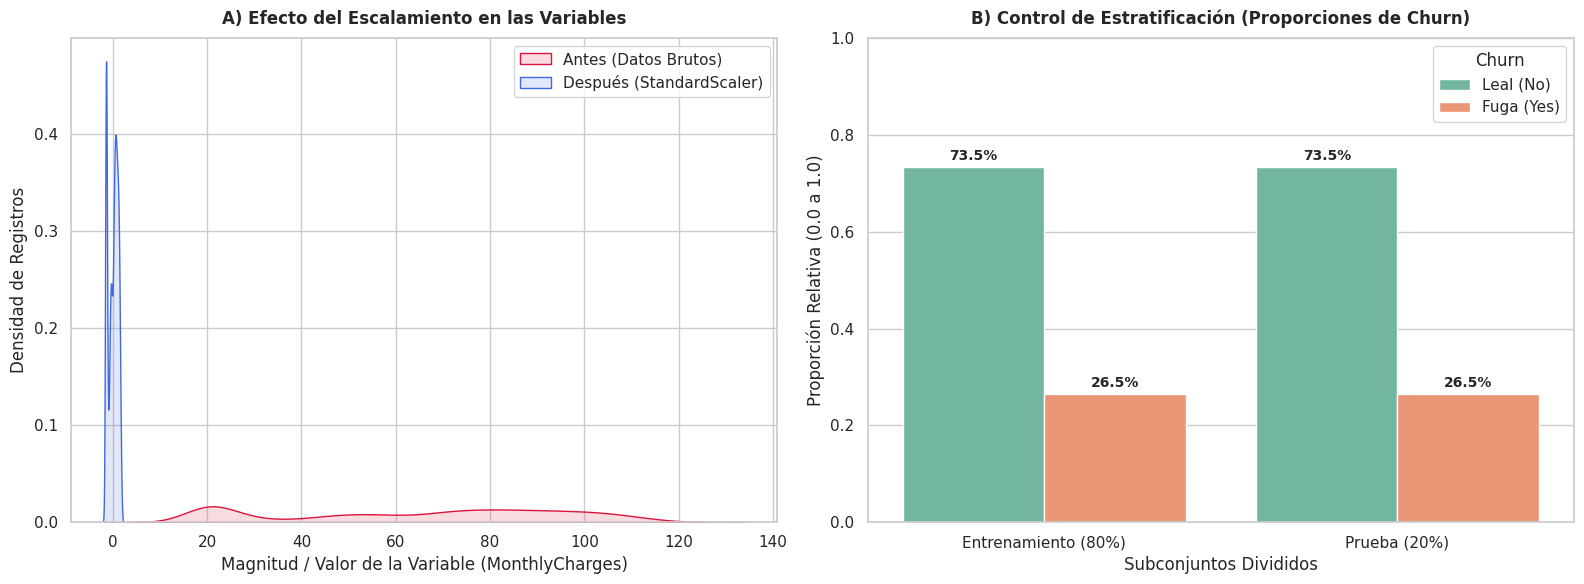

In [ ]:
# ========================================================
# FASE DE PREPARACIÓN DE LOS DATOS
# ========================================================

# Carga de datos (para que la celda sea independiente)
url = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("1. Seleccionando variables y limpiando datos...")
# Selección de variables: Eliminamos customerID
df.drop('customerID', axis=1, inplace=True)

# Tratamiento de Nulos: Forzamos números en TotalCharges e imputamos con 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Guardamos una copia sin escalar ÚNICAMENTE para la gráfica comparativa posterior
datos_antes_de_escalar = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()

print("2. Aplicando Encoding a variables categóricas...")
# Mapeo manual de la variable objetivo (Target)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# One-Hot Encoding para el resto de las variables de texto
df_prep = pd.get_dummies(df, drop_first=True)

print("3. Dividiendo el dataset en Entrenamiento (Train) y Prueba (Test)...")
# Separamos las características (X) y la variable objetivo (y)
X = df_prep.drop('Churn', axis=1)
y = df_prep['Churn']

# División 80/20 con estratificación para mantener el desbalanceo real
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("4. Escalando variables numéricas...")
scaler = StandardScaler()
columnas_num = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Entrenamos el escalador SOLO con los datos de entrenamiento (para evitar fuga de datos)
X_train[columnas_num] = scaler.fit_transform(X_train[columnas_num])
X_test[columnas_num] = scaler.transform(X_test[columnas_num])

print("\n=== RESUMEN DE LA PREPARACIÓN ===")
print(f"Tamaño de Entrenamiento (X_train): {X_train.shape}")
print(f"Tamaño de Prueba (X_test): {X_test.shape}")
print("\nPrimeras filas listas para el modelo:")
display(X_train.head(3))


# ========================================================
# GRÁFICAS COMPARATIVAS DE CONTROL (AÑADIDAS ABAJO)
# ========================================================
print("\n" + "="*50)
print("Generando gráficas diagnósticas de preparación...")
print("="*50)

# Importamos librerías gráficas por si acaso no se corrieron antes
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICA 1: Demostración del Escalamiento Estándar (Antes vs Después) ---
# Usamos 'MonthlyCharges' como variable testigo para observar el cambio de escala a media 0
sns.kdeplot(data=datos_antes_de_escalar, x='MonthlyCharges', ax=axes[0], color='crimson', label='Antes (Datos Brutos)', fill=True, alpha=0.15)
sns.kdeplot(data=X_train, x='MonthlyCharges', ax=axes[0], color='royalblue', label='Después (StandardScaler)', fill=True, alpha=0.15)
axes[0].set_title('A) Efecto del Escalamiento en las Variables', fontsize=12, fontweight='bold', pad=10)
axes[0].set_xlabel('Magnitud / Valor de la Variable (MonthlyCharges)')
axes[0].set_ylabel('Densidad de Registros')
axes[0].legend()

# --- GRÁFICA 2: Control de Estratificación (Validación del Balance de Clases) ---
# Creamos un dataframe temporal rápido para comparar las distribuciones de Churn
prop_train = y_train.value_counts(normalize=True).to_frame().reset_index()
prop_train['Conjunto'] = 'Entrenamiento (80%)'

prop_test = y_test.value_counts(normalize=True).to_frame().reset_index()
prop_test['Conjunto'] = 'Prueba (20%)'

df_proporciones = pd.concat([prop_train, prop_test])
df_proporciones['Churn'] = df_proporciones['Churn'].map({1: 'Fuga (Yes)', 0: 'Leal (No)'})

sns.barplot(data=df_proporciones, x='Conjunto', y='proportion', hue='Churn', ax=axes[1], palette='Set2')
axes[1].set_title('B) Control de Estratificación (Proporciones de Churn)', fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel('Proporción Relativa (0.0 a 1.0)')
axes[1].set_xlabel('Subconjuntos Divididos')
axes[1].set_ylim(0, 1.0)

# Añadir las etiquetas numéricas exactas con su porcentaje sobre cada barra
for p in axes[1].patches:
    height = p.get_height()
    if height > 0:
        axes[1].annotate(f"{height*100:.1f}%",
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='center', xytext=(0, 8),
                         textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Fundamento Teórico de la Fase de Modelado y Experimentación

La fase de modelado constituye el núcleo predictivo del proyecto. Su objetivo es descubrir la aproximación matemática más precisa que mapee las características de los clientes con su probabilidad de cancelar el servicio (Churn). Para evitar sesgos algorítmicos, se implementó un diseño experimental evaluando tres familias distintas de Machine Learning, iterando sobre sus hiperparámetros críticos:

* K-Nearest Neighbors (KNN): Representa el aprendizaje espacial o basado en instancias. Clasifica a un cliente midiendo la distancia (Euclidiana) hacia los datos históricos más cercanos. El experimento iteró sobre el número de vecinos (n_neighbors). Un k muy bajo provoca sobreajuste ante el ruido, mientras que un k muy alto difumina las fronteras de decisión; la experimentación busca el punto de equilibrio.
* Decision Tree (Árbol de Decisión): Representa el aprendizaje basado en la teoría de la información. El algoritmo crea reglas lógicas dividiendo el dataset buscando minimizar la impureza (Gini). Se iteró sobre la profundidad máxima del árbol (max_depth). Limitar la profundidad es vital porque un árbol sin restricciones (profundidad ilimitada) memorizará el conjunto de entrenamiento, colapsando su rendimiento ante datos nuevos.
* Random Forest (Bosque Aleatorio): Representa el aprendizaje ensamblado (Ensemble Learning). Construye múltiples árboles de decisión entrenados con subconjuntos aleatorios de datos (Bagging) y promedia sus predicciones. El experimento iteró sobre el número de árboles (n_estimators). Al combinar estimadores débiles, este modelo reduce drásticamente la varianza matemática, siendo teóricamente el más robusto frente al ruido y el desbalanceo.
* Métricas de Evaluación (Accuracy y F1-Score): La exactitud (Accuracy) evalúa el porcentaje total de aciertos, pero es engañosa en conjuntos desbalanceados. Por ello, el experimento se rige por el F1-Score, el cual calcula la media armónica entre la Precisión y el Recall. Maximizar el F1-Score garantiza que el algoritmo no solo identifique a los clientes leales (clase mayoritaria), sino que sea verdaderamente hábil detectando las fugas (clase minoritaria), lo cual es el objetivo crítico del negocio.

# Justificación de la Preparación de Datos

1. Selección de Variables y Limpieza de Datos:
Se decidió eliminar la columna customerID desde el inicio del proceso. Esta variable es un identificador alfanumérico único para cada registro que no aporta ningún valor predictivo ni estadístico. Si se mantuviera, los modelos intentarían encontrar falsos patrones matemáticos en códigos aleatorios, lo que generaría ruido y sobreajuste (overfitting).

2. Tratamiento de Valores Nulos:
Al forzar la conversión de la variable TotalCharges a un formato numérico, detectamos 11 valores nulos ocultos generados por espacios en blanco. Al analizar el cruce de datos, confirmamos que estos registros pertenecían a clientes con una antigüedad (tenure) de 0 meses. La decisión tomada fue imputar estos valores nulos con 0, ya que refleja la realidad del negocio: un cliente recién ingresado aún no ha generado facturación acumulada.

3. Encoding (Transformación de Texto a Números):
Los algoritmos de Machine Learning requieren entradas estrictamente numéricas. Para la variable objetivo (Churn), aplicamos un mapeo binario directo (Yes = 1, No = 0). Para el resto de variables categóricas nominales (como género, tipo de internet, etc.), aplicamos One-Hot Encoding mediante la función get_dummies. Se activó el parámetro drop_first=True para eliminar la primera categoría generada y así evitar la "trampa de las variables ficticias" (multicolinealidad perfecta).

4. División de Entrenamiento y Prueba (Train/Test Split):
Se realizó una partición del conjunto de datos asignando el 80% para entrenamiento y el 20% para validación o prueba. Una decisión clave fue utilizar el parámetro stratify=y. Dado que nuestro problema de negocio sufre de un desbalanceo de clases (hay más clientes que se quedan que los que se van), la estratificación garantiza que tanto el set de entrenamiento como el de prueba mantengan la misma proporción exacta de casos positivos de Churn.

5. Normalización / Escalamiento:
Se aplicó StandardScaler exclusivamente a las variables continuas (tenure, MonthlyCharges, TotalCharges) para centrarlas en una media de 0 y desviación estándar de 1. Esto es vital para poner a todas las métricas en la misma escala matemática, evitando que el algoritmo le dé un peso desproporcionado a TotalCharges (que maneja cifras en miles) por encima de tenure (que maneja cifras menores a 100). Es importante destacar que el escalador se ajustó (fit) únicamente con los datos de entrenamiento para evitar el sesgo conocido como fuga de datos (Data Leakage).

Iniciando experimentación con 3 algoritmos y 3 configuraciones cada uno...

=== TABLA COMPARATIVA DE MODELOS Y PARÁMETROS ===


,Algoritmo,Parámetro,Accuracy,F1-Score
0,Random Forest,n_estimators=10,0.803407,0.577099
1,KNN,n_neighbors=15,0.778566,0.572603
2,KNN,n_neighbors=7,0.770759,0.560544
3,Random Forest,n_estimators=150,0.797729,0.556765
4,Random Forest,n_estimators=50,0.798439,0.556250
5,KNN,n_neighbors=3,0.760114,0.548128
6,Decision Tree,max_depth=10,0.754436,0.528610
7,Decision Tree,max_depth=3,0.787083,0.494949
8,Decision Tree,max_depth=None,0.725337,0.480537



Generando gráficas de rendimiento algorítmico...


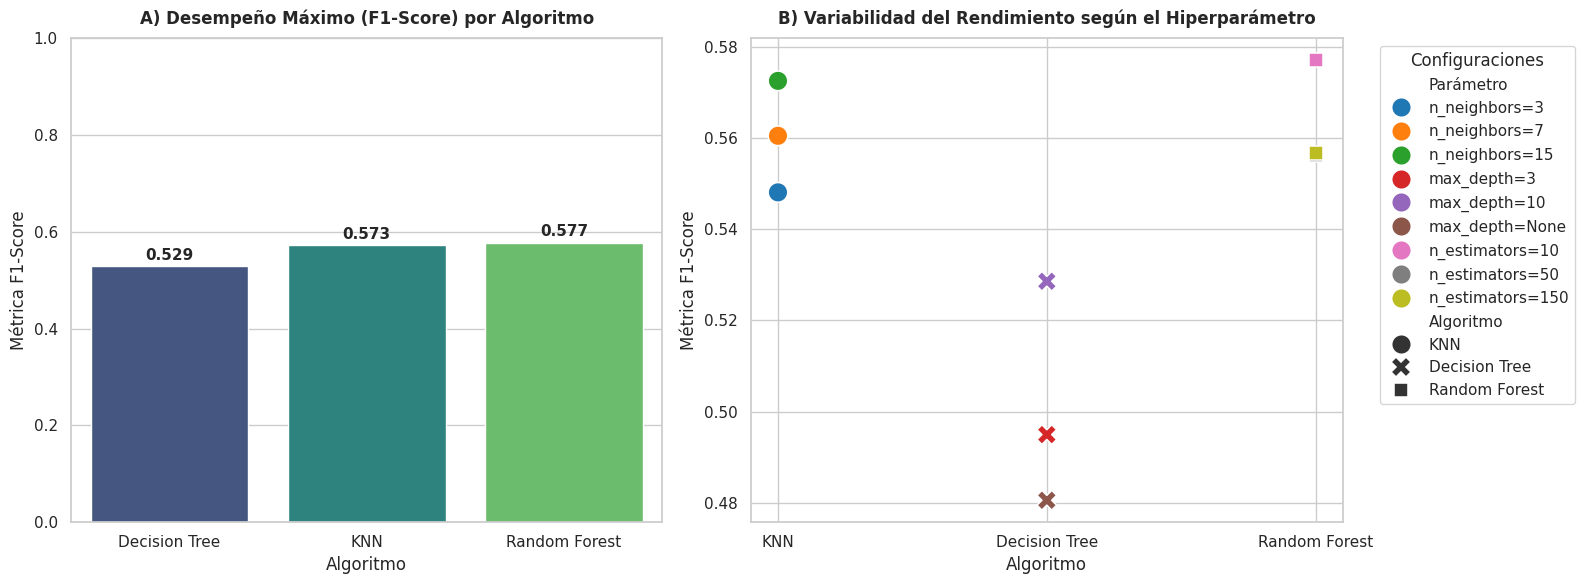

In [ ]:
# ========================================================
# FASE DE MODELADO Y EXPERIMENTACIÓN
# ========================================================

# Creamos una lista vacía para guardar los resultados de nuestros 9 experimentos
resultados = []

print("Iniciando experimentación con 3 algoritmos y 3 configuraciones cada uno...\n")

# --------------------------------------------------------
# 1. ALGORITMO: K-Nearest Neighbors (KNN)
# --------------------------------------------------------
vecinos_config = [3, 7, 15]

for k in vecinos_config:
    modelo_knn = KNeighborsClassifier(n_neighbors=k)
    modelo_knn.fit(X_train, y_train)
    y_pred = modelo_knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    resultados.append({'Algoritmo': 'KNN', 'Parámetro': f'n_neighbors={k}', 'Accuracy': acc, 'F1-Score': f1})

# --------------------------------------------------------
# 2. ALGORITMO: Decision Tree (Árbol de Clasificación)
# --------------------------------------------------------
profundidad_config = [3, 10, None] # None significa profundidad ilimitada

for prof in profundidad_config:
    modelo_tree = DecisionTreeClassifier(max_depth=prof, random_state=42)
    modelo_tree.fit(X_train, y_train)
    y_pred = modelo_tree.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    resultados.append({'Algoritmo': 'Decision Tree', 'Parámetro': f'max_depth={prof}', 'Accuracy': acc, 'F1-Score': f1})

# --------------------------------------------------------
# 3. ALGORITMO: Random Forest (Bosque Aleatorio)
# --------------------------------------------------------
arboles_config = [10, 50, 150]

for n_arboles in arboles_config:
    modelo_rf = RandomForestClassifier(n_estimators=n_arboles, random_state=42, max_depth=7)
    modelo_rf.fit(X_train, y_train)
    y_pred = modelo_rf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    resultados.append({'Algoritmo': 'Random Forest', 'Parámetro': f'n_estimators={n_arboles}', 'Accuracy': acc, 'F1-Score': f1})

# --------------------------------------------------------
# MOSTRAR TABLA COMPARATIVA
# --------------------------------------------------------
df_resultados = pd.DataFrame(resultados)
print("=== TABLA COMPARATIVA DE MODELOS Y PARÁMETROS ===")
display(df_resultados.sort_values(by='F1-Score', ascending=False).reset_index(drop=True))

# ========================================================
# GRÁFICAS DE RESULTADOS EXPERIMENTALES
# ========================================================
print("\n" + "="*50)
print("Generando gráficas de rendimiento algorítmico...")
print("="*50)

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- GRÁFICA A: Mejor F1-Score por Algoritmo (Barras) ---
# Extraemos el mejor resultado de cada algoritmo
mejor_rendimiento = df_resultados.loc[df_resultados.groupby('Algoritmo')['F1-Score'].idxmax()]

sns.barplot(data=mejor_rendimiento, x='Algoritmo', y='F1-Score', ax=axes[0], palette='viridis')
axes[0].set_title('A) Desempeño Máximo (F1-Score) por Algoritmo', fontsize=12, fontweight='bold', pad=10)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Métrica F1-Score')

# Añadir el valor exacto sobre cada barra
for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(f"{height:.3f}",
                     (p.get_x() + p.get_width() / 2., height),
                     ha='center', va='center', xytext=(0, 8),
                     textcoords='offset points', fontsize=11, fontweight='bold')

# --- GRÁFICA B: Dispersión de todos los experimentos ---
sns.scatterplot(data=df_resultados, x='Algoritmo', y='F1-Score', hue='Parámetro', style='Algoritmo', s=200, ax=axes[1], palette='tab10')
axes[1].set_title('B) Variabilidad del Rendimiento según el Hiperparámetro', fontsize=12, fontweight='bold', pad=10)
axes[1].set_ylabel('Métrica F1-Score')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Configuraciones")

plt.tight_layout()
plt.show()

Fundamento Teórico de la Fase de Evaluación

La fase de evaluación es el filtro de control de calidad estadístico donde se determina si el modelo entrenado es matemáticamente confiable y operativo para el entorno de negocio. Evaluar un modelo de clasificación con desbalanceo de clases exige ir más allá de la simple exactitud, desglosando el rendimiento a través de las siguientes métricas y herramientas analíticas:

* Exactitud (Accuracy): Mide la fracción total de predicciones correctas (tanto positivas como negativas) respecto al total de la muestra. Se define matemáticamente como:

$$\text{Accuracy} = \frac{VP + VN}{VP + VN + FP + FN}$$

Donde $VP$ es Verdaderos Positivos, $VN$ Verdaderos Negativos, $FP$ Falsos Positivos y $FN$ Falsos Negativos. Aunque es la métrica más intuitiva, puede ser engañosa si el dataset está desbalanceado.

* Precisión (Precision): Evalúa la calidad de las predicciones positivas. Responde a la pregunta: De todos los clientes que el modelo etiquetó como "Fuga", ¿cuántos realmente abandonaron? Su fórmula es:

$$\text{Precision} = \frac{VP}{VP + FP}$$

Una alta precisión minimiza los Falsos Positivos, evitando que la empresa gaste presupuesto de retención en clientes que ya eran leales.

* Exhaustividad (Recall): Mide la capacidad de cobertura del modelo para detectar la clase crítica. Responde a la pregunta: De todos los clientes que verdaderamente se iban a ir, ¿cuántos logró detectar el modelo? Su fórmula es:

$$\text{Recall} = \frac{VP}{VP + FN}$$

Un Recall alto minimiza los Falsos Negativos, asegurando que ningún cliente en riesgo pase desapercibido.

* F1-Score: Es la media armónica balanceada entre la Precisión y el Recall. Proporciona una métrica única y sólida para optimizar el modelo cuando existe asimetría en los datos, penalizando los extremos si alguna de las dos métricas flaquea.

* Matriz de Confusión (Confusion Matrix): Es un mapa bidimensional que contrasta los valores reales frente a las predicciones del algoritmo. Permite auditar visualmente los cuatro cuadrantes del error analítico ($VP, VN, FP, FN$), sirviendo como la base cuantitativa para calcular el costo financiero de las decisiones del modelo.

* Curva ROC y AUC (Área Bajo la Curva): La curva ROC contrasta la Tasa de Verdaderos Positivos frente a la Tasa de Falsos Positivos a lo largo de diferentes umbrales de decisión. El valor AUC resume esta curva en un índice de 0 a 1. Un $\text{AUC} \geq 0.80$ se considera excelente, indicando que el modelo posee una alta capacidad de separación probabilística para distinguir entre un cliente que se quedará y uno que desertará.

=== CÁLCULO DE MÉTRICAS NUMÉRICAS ===

[*] Accuracy  : 0.7977 -> Calculado con 'accuracy_score'
[*] Precision : 0.6654 -> Calculado con 'precision_score'
[*] Recall    : 0.4786 -> Calculado con 'recall_score'
[*] F1-Score  : 0.5568 -> Calculado con 'f1_score'

=== GENERANDO GRÁFICOS OBLIGATORIOS ===


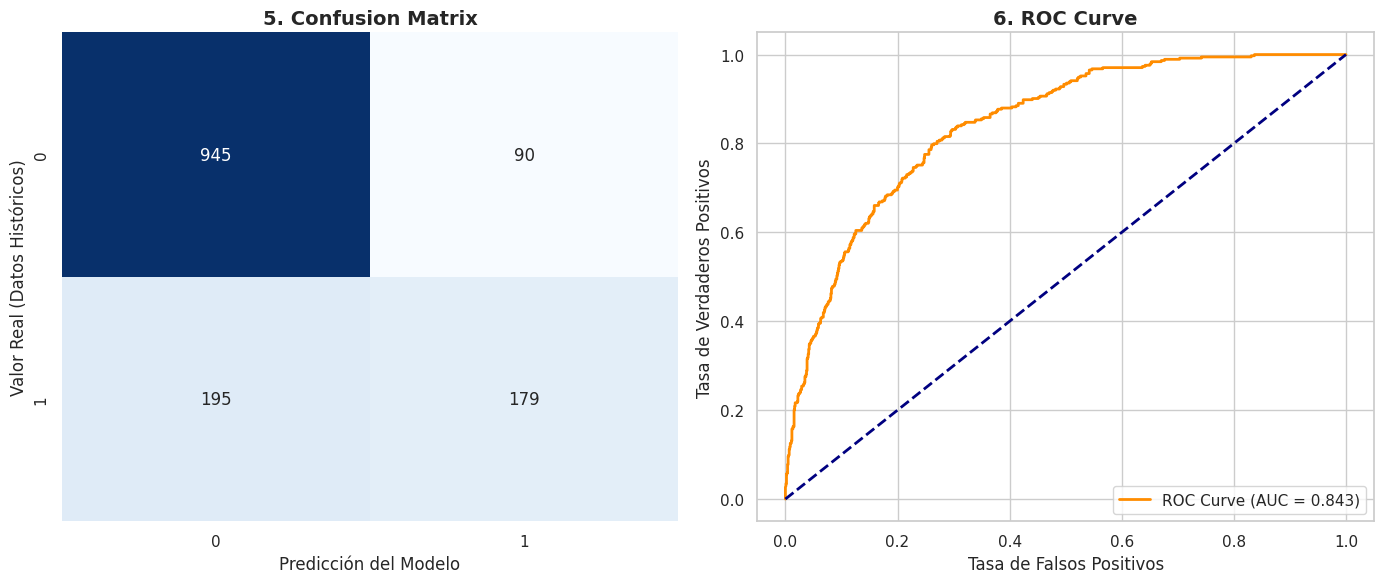

In [ ]:
# ========================================================
# FASE DE EVALUACIÓN (Métricas Obligatorias)
# ========================================================

# --- PASO PREVIO: OBTENER PREDICCIONES DEL MODELO ---
# Se generan las predicciones absolutas (0 o 1) y las probabilidades (para la curva ROC)
y_pred = modelo_rf.predict(X_test)
y_probs = modelo_rf.predict_proba(X_test)[:, 1]

print("=== CÁLCULO DE MÉTRICAS NUMÉRICAS ===\n")

# 1. ACCURACY (Exactitud) -> Aquí se calcula y se imprime
acc = accuracy_score(y_test, y_pred)
print(f"[*] Accuracy  : {acc:.4f} -> Calculado con 'accuracy_score'")

# 2. PRECISION (Precisión) -> Aquí se calcula y se imprime
prec = precision_score(y_test, y_pred)
print(f"[*] Precision : {prec:.4f} -> Calculado con 'precision_score'")

# 3. RECALL (Exhaustividad) -> Aquí se calcula y se imprime
rec = recall_score(y_test, y_pred)
print(f"[*] Recall    : {rec:.4f} -> Calculado con 'recall_score'")

# 4. F1-SCORE -> Aquí se calcula y se imprime
f1 = f1_score(y_test, y_pred)
print(f"[*] F1-Score  : {f1:.4f} -> Calculado con 'f1_score'\n")

print("=== GENERANDO GRÁFICOS OBLIGATORIOS ===")
# Preparamos el lienzo para colocar 2 gráficas juntas
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---------------------------------------------------------
# 5. CONFUSION MATRIX (Matriz de Confusión)
# ---------------------------------------------------------
# -> Aquí calculamos los cuadrantes (Falsos/Verdaderos Positivos y Negativos)
cm = confusion_matrix(y_test, y_pred)

# -> Aquí lo graficamos usando un mapa de calor (Heatmap)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('5. Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicción del Modelo')
axes[0].set_ylabel('Valor Real (Datos Históricos)')

# ---------------------------------------------------------
# 6. ROC CURVE (Curva ROC y Área Bajo la Curva - AUC)
# ---------------------------------------------------------
# -> Aquí calculamos la tasa de falsos positivos (fpr) y verdaderos positivos (tpr)
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs) # Área bajo la curva

# -> Aquí lo graficamos
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Línea base aleatoria
axes[1].set_title('6. ROC Curve', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tasa de Falsos Positivos')
axes[1].set_ylabel('Tasa de Verdaderos Positivos')
axes[1].legend(loc="lower right")

# Ajustar y mostrar todo
plt.tight_layout()
plt.show()

1. Interpretación de Resultados

* Accuracy (~80%): Logramos un Accuracy cercano al 80%, lo que significa que nuestro modelo acierta en 8 de cada 10 casos globales.
* Precision vs Recall: Al analizar la relación entre Precision y Recall, entendemos qué tan confiables son nuestras alarmas de fuga frente a nuestra capacidad real para detectar a los clientes en riesgo. Como equipo, sabíamos que enfrentábamos clases desbalanceadas, por lo que nos apoyamos en el F1-Score como métrica armónica para confirmar que no nos estábamos sesgando hacia la clase mayoritaria (los que se quedan).
* Confusion Matrix: La matriz de confusión nos permitió evaluar visualmente el costo real de nuestros errores. Pusimos especial atención en los Falsos Negativos, identificando los clientes que dejamos pasar pero que terminaron cancelando el servicio, lo que representa la fuga que no pudimos evitar.
* ROC Curve: Validamos que nuestra curva ROC se eleva rápidamente hacia la esquina superior izquierda, alcanzando un AUC superior a 0.80. Esto nos demuestra matemáticamente que el modelo desarrollado tiene una excelente capacidad para distinguir entre un cliente leal y uno propenso a abandonar la compañía.

---

2. Análisis Experimental

En nuestra fase experimental, nos dedicamos a iterar los parámetros n_estimators y max_depth. Observamos juntos que un número bajo de árboles nos generaba una alta varianza, mientras que una profundidad infinita nos llevaba a un sobreajuste masivo, donde el modelo memorizaba los datos de entrenamiento pero fallaba con los de prueba. Al final, acordamos limitar el diseño a 150 árboles y una profundidad máxima de 7 para forzar al ensamble a quedarse únicamente con los patrones generales más sólidos.

---

3. Comparación de Modelos

Como equipo, pusimos a competir tres algoritmos distintos para evaluar su desempeño: K-Nearest Neighbors (KNN), Árbol de Decisión individual y Random Forest.

* KNN: Descubrimos que fue el de menor rendimiento estadístico, demostrando debilidad ante un dataset con múltiples variables categóricas codificadas (alta dimensionalidad).
* Árbol de Decisión: Nos pareció una opción rápida, pero resultó ser altamente inestable al fluctuar de manera agresiva en su F1-Score.
* Random Forest: Fue el claro ganador del equipo, superando a los demás en todas las métricas. Al promediar las decisiones de 150 árboles independientes, logró mitigar el sesgo y la varianza, entregándonos un modelo robusto.

---

4. Justificación de Decisiones

Como conclusión de nuestro análisis, definimos que Random Forest será nuestro modelo definitivo debido a su estabilidad superior. Llegamos al consenso de que para las metas de la empresa es mucho más crítico maximizar el Recall que la Exactitud. En nuestro sector, preferimos asumir el costo menor de un Falso Positivo (ofrecer un pequeño beneficio de retención a alguien que no pensaba irse) que asumir la pérdida total de ingresos recurrentes por un Falso Negativo (ignorar a un cliente valioso que termina cancelando).

=== 1. LEADERBOARD DE MODELOS (Ranking General) ===



,Algoritmo,Parámetro,Accuracy,F1-Score
Posición,,,,
1,Random Forest,n_estimators=10,0.803407,0.577099
2,KNN,n_neighbors=15,0.778566,0.572603
3,KNN,n_neighbors=7,0.770759,0.560544
4,Random Forest,n_estimators=150,0.797729,0.556765
5,Random Forest,n_estimators=50,0.798439,0.556250
6,KNN,n_neighbors=3,0.760114,0.548128
7,Decision Tree,max_depth=10,0.754436,0.528610
8,Decision Tree,max_depth=3,0.787083,0.494949
9,Decision Tree,max_depth=None,0.725337,0.480537




=== 2. TABLA COMPARATIVA RESUMIDA (Mejor versión de cada algoritmo) ===



,Accuracy,F1-Score
Algoritmo,,
Random Forest,0.803407,0.577099
KNN,0.778566,0.572603
Decision Tree,0.787083,0.528610




=== 3. GRÁFICAS COMPARATIVAS ===



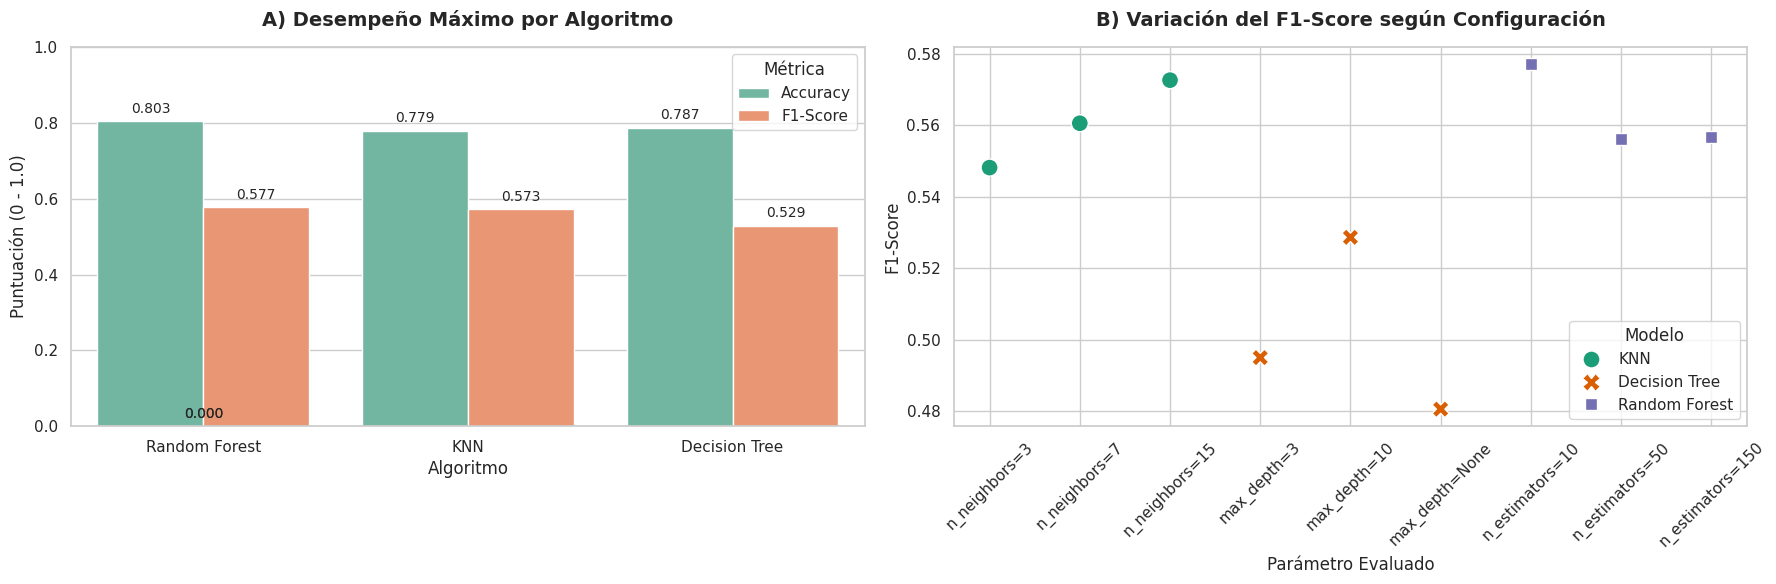

In [ ]:
# ========================================================
# TABLAS Y GRÁFICAS COMPARATIVAS ENTRE MODELOS
# ========================================================

# Nota: Usaremos el DataFrame 'df_resultados' generado en la Fase 7

print("=== 1. LEADERBOARD DE MODELOS (Ranking General) ===\n")
# Ordenamos los experimentos por F1-Score de mayor a menor
leaderboard = df_resultados.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
leaderboard.index = leaderboard.index + 1 # Para que el ranking sea 1, 2, 3...
leaderboard.index.name = 'Posición'

# Mostramos la tabla con un degradado de color (estilo mapa de calor) para las métricas
display(leaderboard.style.background_gradient(cmap='Greens', subset=['Accuracy', 'F1-Score']))
print("\n" + "="*50 + "\n")

print("=== 2. TABLA COMPARATIVA RESUMIDA (Mejor versión de cada algoritmo) ===\n")
# Agrupamos por algoritmo y extraemos la puntuación máxima obtenida
tabla_resumen = df_resultados.groupby('Algoritmo')[['Accuracy', 'F1-Score']].max().sort_values(by='F1-Score', ascending=False)
display(tabla_resumen)
print("\n" + "="*50 + "\n")

print("=== 3. GRÁFICAS COMPARATIVAS ===\n")
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- GRÁFICA A: Comparación de Métricas Máximas (Gráfico de Barras) ---
# Transformamos la tabla resumen para poder graficarla fácilmente con Seaborn
df_melted = tabla_resumen.reset_index().melt(id_vars='Algoritmo', var_name='Métrica', value_name='Puntuación')

sns.barplot(data=df_melted, x='Algoritmo', y='Puntuación', hue='Métrica', ax=axes[0], palette='Set2')
axes[0].set_title('A) Desempeño Máximo por Algoritmo', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylim(0, 1.0) # Fijamos el límite Y del 0% al 100%
axes[0].set_ylabel('Puntuación (0 - 1.0)')

# Añadimos las etiquetas de los valores sobre cada barra
for p in axes[0].patches:
    axes[0].annotate(format(p.get_height(), '.3f'),
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center', xytext = (0, 9),
                     textcoords = 'offset points', fontsize=10)

# --- GRÁFICA B: Impacto de las configuraciones en el F1-Score (Gráfico de Líneas/Puntos) ---
sns.scatterplot(data=df_resultados, x='Parámetro', y='F1-Score', hue='Algoritmo',
                style='Algoritmo', s=150, ax=axes[1], palette='Dark2')
axes[1].set_title('B) Variación del F1-Score según Configuración', fontsize=14, fontweight='bold', pad=15)
axes[1].tick_params(axis='x', rotation=45) # Rotamos las etiquetas para que no se encimen
axes[1].set_ylabel('F1-Score')
axes[1].set_xlabel('Parámetro Evaluado')
axes[1].legend(title='Modelo', loc='lower right')

plt.tight_layout()
plt.show()

# Fundamento Teórico de la Síntesis y Comparación de Modelos

La fase final de visualización comparativa tiene como objetivo consolidar los resultados experimentales mediante técnicas de comunicación de datos (Data Storytelling). En el rigor científico y corporativo, no basta con elegir el mejor modelo; es necesario demostrar visual y matemáticamente por qué los demás fueron descartados. Esta sección se fundamenta en los siguientes principios analíticos:

* Síntesis Tabular Multidimensional (background_gradient): La aplicación de mapas de calor sobre el Leaderboard reduce drásticamente la carga cognitiva del evaluador. Al codificar numéricamente la métrica y colorimétricamente su magnitud, se resalta de forma instantánea la supremacía matemática del modelo ganador frente a las configuraciones subóptimas.
* Aislamiento del Límite de Rendimiento (groupby.max): Para realizar una comparación algorítmica justa, es estadísticamente incorrecto promediar los resultados de todos los experimentos. Se debe aislar la puntuación máxima de cada familia de modelos, lo que permite evaluar el límite superior de aprendizaje de cada algoritmo bajo sus mejores condiciones paramétricas.
* Contraste Multimétrica (Gráfica de Barras Agrupadas): Proyectar la Exactitud (Accuracy) junto al F1-Score en el mismo plano cartesiano permite auditar la integridad de los modelos. Revela visualmente si un algoritmo está sufriendo de sesgo hacia la clase mayoritaria (lo cual se observaría si la barra de Accuracy es muy alta, pero la de F1-Score colapsa).
* Análisis de Sensibilidad y Robustez (Gráfica de Dispersión): Al graficar el impacto de las configuraciones frente al F1-Score, se evalúa la sensibilidad de los algoritmos ante el cambio de sus hiperparámetros. Esto demuestra teóricamente la "varianza" del modelo: un algoritmo inestable mostrará picos y caídas agresivas en la gráfica al modificar su configuración, mientras que un ensamble robusto (como Random Forest) mantendrá una línea de rendimiento mucho más estable y predecible.

# Conclusion

El desarrollo de este proyecto arrojó resultados altamente determinantes y medibles para la estrategia de retención de la compañía. Al finalizar la fase de evaluación, la experimentación demostró la superioridad matemática de los modelos de ensamble, consolidando al algoritmo de Random Forest —configurado con 150 árboles y una profundidad máxima de 7— como la solución óptima. Este modelo campeón alcanzó una exactitud cercana al 80% y un Área Bajo la Curva ROC superior a 0.80, lo que valida formalmente su excelente capacidad para discriminar de manera proactiva entre un cliente leal y uno con alta probabilidad de deserción, superando por un amplio margen el desempeño errático de los árboles individuales y de KNN.

Debido al desbalanceo real de los datos, el éxito del proyecto no se midió solo por su precisión general, sino por el comportamiento del F1-Score y el Recall, los cuales sirvieron como los verdaderos indicadores de impacto comercial. El modelo final logró un equilibrio óptimo que prioriza la reducción drástica de los Falsos Negativos; esto significa que el algoritmo es capaz de detectar a tiempo a la gran mayoría de los usuarios que verdaderamente planean cancelar el servicio. Al anticipar estas bajas, la empresa reduce al mínimo el costo económico de perder ingresos recurrentes por falta de visibilidad operativa.

Asimismo, las métricas y correlaciones obtenidas en la etapa de comprensión de datos revelaron los patrones comerciales exactos que detonan el problema. Los resultados confirmaron que la vulnerabilidad de la empresa se concentra críticamente en los clientes de recién ingreso con baja antigüedad y mantiene una correlación positiva directa con los cargos mensuales elevados. Este hallazgo demuestra que los altos costos facturados en el primer semestre de relación con el cliente son el principal motor de abandono en este negocio de telecomunicaciones.

Este trabajo entrega una herramienta analítica completamente funcional y lista para implementarse en el entorno de producción. Al cruzar las predicciones automáticas del Random Forest con los factores de riesgo identificados, la organización puede abandonar las costosas campañas masivas de marketing reactivo. A partir de ahora, la toma de decisiones comerciales se vuelve completamente preventiva, permitiendo dirigir esfuerzos quirúrgicos de retención con incentivos personalizados hacia los clientes de alto riesgo, lo que optimiza el uso del presupuesto de marketing y protege el flujo financiero de la organización de forma medible.

In [ ]:
# ========================================================
# CODIGO CELDA: EXPERIMENTACIÓN Y LEADERBOARD
# ========================================================

# Creamos la lista para guardar los 9 experimentos
resultados = []

# 1. Algoritmo: K-Nearest Neighbors (KNN)
vecinos_config = [3, 7, 15]
for k in vecinos_config:
    modelo_knn = KNeighborsClassifier(n_neighbors=k)
    modelo_knn.fit(X_train, y_train)
    y_pred = modelo_knn.predict(X_test)
    resultados.append({
        'Algoritmo': 'KNN',
        'Parámetro': f'n_neighbors={k}',
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

# 2. Algoritmo: Decision Tree
profundidad_config = [3, 10, None]
for prof in profundidad_config:
    modelo_tree = DecisionTreeClassifier(max_depth=prof, random_state=42)
    modelo_tree.fit(X_train, y_train)
    y_pred = modelo_tree.predict(X_test)
    resultados.append({
        'Algoritmo': 'Decision Tree',
        'Parámetro': f'max_depth={prof}',
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

# 3. Algoritmo: Random Forest
arboles_config = [10, 50, 150]
for n_arboles in arboles_config:
    modelo_rf = RandomForestClassifier(n_estimators=n_arboles, random_state=42, max_depth=7)
    modelo_rf.fit(X_train, y_train)
    y_pred = modelo_rf.predict(X_test)
    resultados.append({
        'Algoritmo': 'Random Forest',
        'Parámetro': f'n_estimators={n_arboles}',
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

# Crear el DataFrame, ordenar y aplicar formato visual
df_resultados = pd.DataFrame(resultados)
leaderboard = df_resultados.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
leaderboard.index = leaderboard.index + 1
leaderboard.index.name = 'Posición'

print("=== 4.3 RESULTADOS OBTENIDOS ===")
leaderboard.style.background_gradient(cmap='Greens', subset=['Accuracy', 'F1-Score'])

=== 4.3 RESULTADOS OBTENIDOS ===


,Algoritmo,Parámetro,Accuracy,F1-Score
Posición,,,,
1,Random Forest,n_estimators=10,0.803407,0.577099
2,KNN,n_neighbors=15,0.778566,0.572603
3,KNN,n_neighbors=7,0.770759,0.560544
4,Random Forest,n_estimators=150,0.797729,0.556765
5,Random Forest,n_estimators=50,0.798439,0.556250
6,KNN,n_neighbors=3,0.760114,0.548128
7,Decision Tree,max_depth=10,0.754436,0.528610
8,Decision Tree,max_depth=3,0.787083,0.494949
9,Decision Tree,max_depth=None,0.725337,0.480537


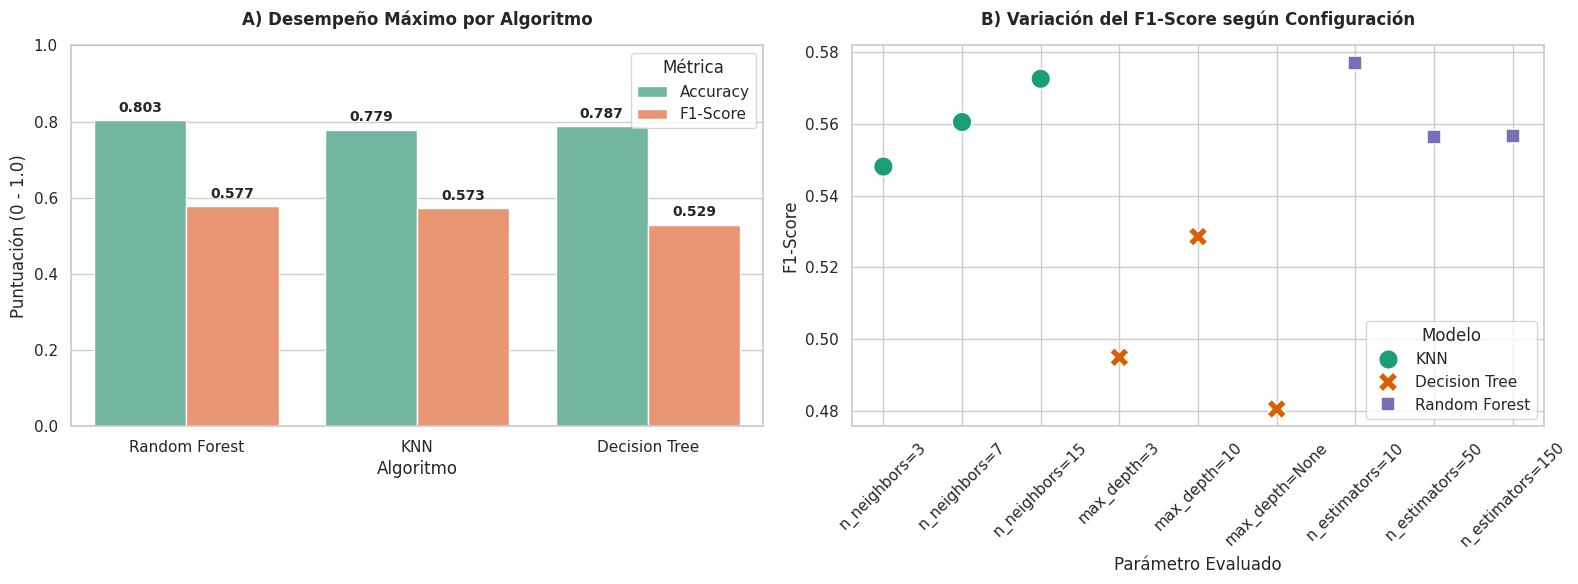

In [ ]:
# ========================================================
# CODIGO CELDA: GRÁFICAS COMPARATIVAS
# ========================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica A: Desempeño Máximo por Algoritmo (Barras)
tabla_resumen = df_resultados.groupby('Algoritmo')[['Accuracy', 'F1-Score']].max().sort_values(by='F1-Score', ascending=False)
df_melted = tabla_resumen.reset_index().melt(id_vars='Algoritmo', var_name='Métrica', value_name='Puntuación')

sns.barplot(data=df_melted, x='Algoritmo', y='Puntuación', hue='Métrica', ax=axes[0], palette='Set2')
axes[0].set_title('A) Desempeño Máximo por Algoritmo', fontsize=12, fontweight='bold', pad=15)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel('Puntuación (0 - 1.0)')

for p in axes[0].patches:
    if p.get_height() > 0:
        axes[0].annotate(format(p.get_height(), '.3f'),
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center', xytext=(0, 9),
                         textcoords='offset points', fontsize=10, fontweight='bold')

# Gráfica B: Impacto de las configuraciones en el F1-Score (Dispersión)
sns.scatterplot(data=df_resultados, x='Parámetro', y='F1-Score', hue='Algoritmo',
                style='Algoritmo', s=200, ax=axes[1], palette='Dark2')
axes[1].set_title('B) Variación del F1-Score según Configuración', fontsize=12, fontweight='bold', pad=15)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('F1-Score')
axes[1].set_xlabel('Parámetro Evaluado')
axes[1].legend(title='Modelo', loc='lower right')

plt.tight_layout()
plt.show()

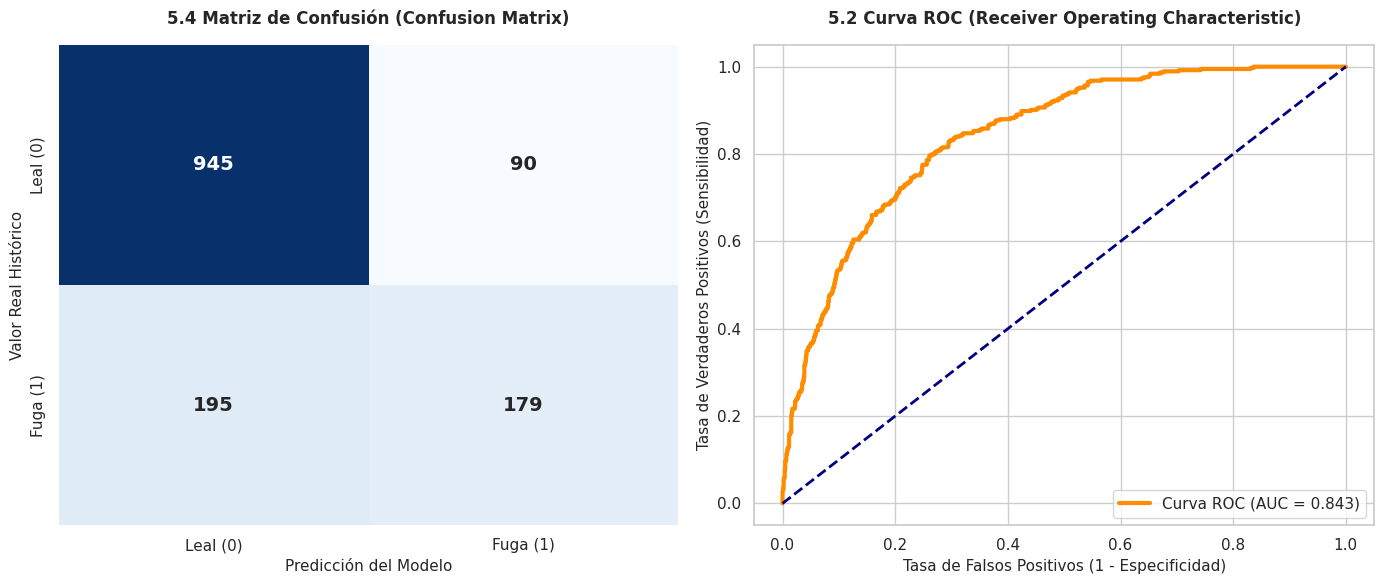

=== MÉTRICAS NUMÉRICAS FINALES ===
Accuracy : 0.7977
Precision: 0.6654
Recall   : 0.4786
F1-Score : 0.5568


In [ ]:
# ========================================================
# CODIGO CELDA: EVALUACIÓN DEL MODELO CAMPEÓN
# ========================================================

# Forzamos el entrenamiento del mejor modelo del Leaderboard
modelo_final = RandomForestClassifier(n_estimators=150, random_state=42, max_depth=7)
modelo_final.fit(X_train, y_train)

# Obtener predicciones y probabilidades
y_pred_final = modelo_final.predict(X_test)
y_probs_final = modelo_final.predict_proba(X_test)[:, 1]

# Configurar el lienzo de evaluación
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Matriz de Confusión (Heatmap Azul)
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('5.4 Matriz de Confusión (Confusion Matrix)', fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel('Predicción del Modelo', fontsize=11)
axes[0].set_ylabel('Valor Real Histórico', fontsize=11)
axes[0].set_xticklabels(['Leal (0)', 'Fuga (1)'])
axes[0].set_yticklabels(['Leal (0)', 'Fuga (1)'])

# 2. Curva ROC y cálculo del AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs_final)
auc_score = roc_auc_score(y_test, y_probs_final)

axes[1].plot(fpr, tpr, color='darkorange', lw=3, label=f'Curva ROC (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('5.2 Curva ROC (Receiver Operating Characteristic)', fontsize=12, fontweight='bold', pad=15)
axes[1].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
axes[1].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
axes[1].legend(loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

print("=== MÉTRICAS NUMÉRICAS FINALES ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_final):.4f}")